# Assignment 3: Linear Models

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, make_scorer

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 19.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

### Q1 ANSWERS
1. A model is "linear" if it is linear in the parameters. In other words, the variables can be any possible value as long as the parameters remain simple. These parameters must not be exponents, divisors, or functions like logarithmic and trigonometry. This means that a parabola ($x^2$) can be "linear" if it has a simple parameter paired with it (such as B($x^2$)).
2. 

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
q2 = pd.read_csv("./data/Q1_clean.csv")
q2.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0000,Manhattan,Apartment,Private room
1,149,100.0000,Brooklyn,Apartment,Entire home/apt
2,250,100.0000,Manhattan,Apartment,Entire home/apt
3,90,94.0000,Brooklyn,Apartment,Private room
4,270,90.0000,Manhattan,Apartment,Entire home/apt


In [5]:
# Clean column names and preserving the original information
q2.columns = [c.strip().replace(" ", "_") for c in q2.columns]

# Attempt to standardize likely column names
rename_map = {}
for c in q2.columns:
    lc = c.lower()
    if "price" in lc and "night" in lc:
        rename_map[c] = "price"
    elif lc == "price":
        rename_map[c] = "price"
    elif "review" in lc and "rating" in lc:
        rename_map[c] = "review_score"
    elif "neighbourhood" in lc or "neighborhood" in lc:
        rename_map[c] = "neighbourhood"
q2 = q2.rename(columns=rename_map)

required_cols_q2 = ["price", "review_score", "neighbourhood"]
print("Columns after renaming:", q2.columns.tolist())
print("Missing required columns:", [c for c in required_cols_q2 if c not in q2.columns])

Columns after renaming: ['price', 'review_score', 'neighbourhood', 'Property_Type', 'Room_Type']
Missing required columns: []


In [6]:
# Cleaning
q2 = q2[required_cols_q2].dropna().copy()
q2["price"] = pd.to_numeric(q2["price"], errors="coerce")
q2["review_score"] = pd.to_numeric(q2["review_score"], errors="coerce")
q2 = q2.dropna().copy()
q2["log_price"] = np.log(q2["price"])

In [7]:
q2.head()

,price,review_score,neighbourhood,log_price
0,549,96.0000,Manhattan,6.3081
1,149,100.0000,Brooklyn,5.0039
2,250,100.0000,Manhattan,5.5215
3,90,94.0000,Brooklyn,4.4998
4,270,90.0000,Manhattan,5.5984


### Q2.1

In [8]:
q2_summary = (
    q2.groupby("neighbourhood")
      .agg(
          avg_price=("price", "mean"),
          median_price=("price", "median"),
          avg_review_score=("review_score", "mean"),
          n=("price", "size")
      )
      .sort_values("avg_price", ascending=False)
)

q2_summary

,avg_price,median_price,avg_review_score,n
neighbourhood,,,,
Manhattan,183.6643,150.0000,91.8015,11763
Staten Island,146.1667,71.0000,90.8438,96
Brooklyn,127.7474,100.0000,92.3635,8487
Queens,96.8572,80.0000,91.5491,1590
Bronx,75.2765,60.0000,91.6544,217


In [9]:
most_expensive_borough = q2_summary.index[0]
most_expensive_price = q2_summary.iloc[0]["avg_price"]

print(f"The most expensive borough on average is {most_expensive_borough} with an average price of {most_expensive_price:,.2f}.")

The most expensive borough on average is Manhattan with an average price of 183.66.


### Q2.2

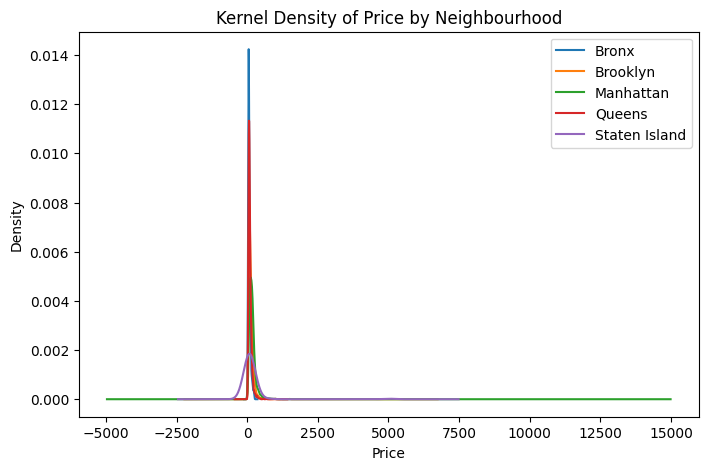

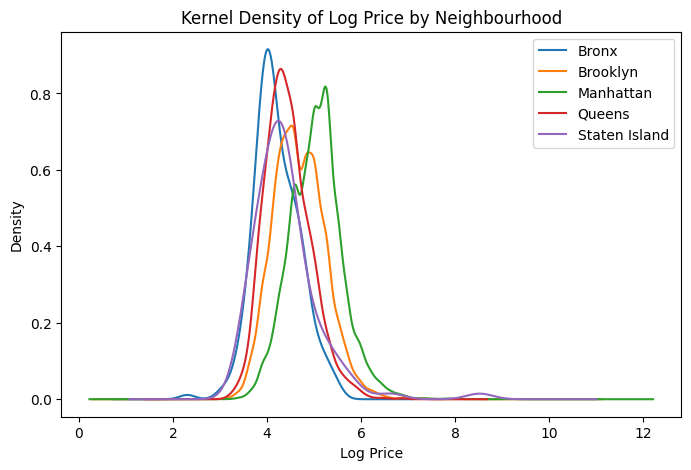

In [10]:
fig, ax = plt.subplots()
for name, grp in q2.groupby("neighbourhood"):
    grp["price"].plot(kind="kde", ax=ax, label=name)
ax.set_title("Kernel Density of Price by Neighbourhood")
ax.set_xlabel("Price")
ax.legend()
plt.show()

fig, ax = plt.subplots()
for name, grp in q2.groupby("neighbourhood"):
    grp["log_price"].plot(kind="kde", ax=ax, label=name)
ax.set_title("Kernel Density of Log Price by Neighbourhood")
ax.set_xlabel("Log Price")
ax.legend()
plt.show()

### Q2.3

In [11]:
# With intercept + drop first category
mod_q2_neigh = smf.ols("price ~ C(neighbourhood)", data=q2).fit()
print(mod_q2_neigh.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        22:39:51   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [12]:
# Compare regression coefficients to group means
baseline = q2["neighbourhood"].astype("category").cat.categories[0]
baseline_mean = q2.loc[q2["neighbourhood"] == baseline, "price"].mean()

coef_table = pd.DataFrame({
    "coefficient": mod_q2_neigh.params
})

print("Baseline category (omitted group):", baseline)
print("Baseline mean price:", baseline_mean)

coef_table

Baseline category (omitted group): Bronx
Baseline mean price: 75.27649769585254


,coefficient
Intercept,75.2765
C(neighbourhood)[T.Brooklyn],52.4709
C(neighbourhood)[T.Manhattan],108.3878
C(neighbourhood)[T.Queens],21.5807
C(neighbourhood)[T.Staten Island],70.8902


By using an intercept and one omitted category, the intercept equals the average price for the baseline neighborhood, and each neighborhood coefficient is equal to its neighborhood's difference of average price and baseline mean. In other words, the regression is printing out what was shown in the group means from the summary table, except that it is in dummy-variable form.   

### Q2.4

In [13]:
mod_q2_review = smf.ols("price ~ review_score", data=q2).fit()
print(mod_q2_review.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        22:46:02   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       60.8784     10.423      5.841   

In [15]:
b0 = mod_q2_review.params["Intercept"]
b1 = mod_q2_review.params["review_score"]

print(f"Intercept: {b0:,.4f}")
print(f"Slope on review_score: {b1:,.4f}")
print()
print(
    f"Interpretation: A one-point increase in review score is associated with an average change "
    f"of {b1:,.4f} in price per night."
)

Intercept: 60.8784
Slope on review_score: 1.0208

Interpretation: A one-point increase in review score is associated with an average change of 1.0208 in price per night.


### Q2.5

In [16]:
mod_q2_both = smf.ols("price ~ C(neighbourhood) + review_score", data=q2).fit()
print(mod_q2_both.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        22:47:26   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [17]:
comparison_q2 = pd.DataFrame({
    "review_only": mod_q2_review.params.reindex(mod_q2_review.params.index),
    "neighbourhood_plus_review": mod_q2_both.params.reindex(mod_q2_review.params.index)
})
comparison_q2


,review_only,neighbourhood_plus_review
Intercept,60.8784,-23.8126
review_score,1.0208,1.0811


When adding neighborhood controls, it can be seen that the review-score slope shows the relationship between review score and price holding neighborhood fixed. Although, if the slope changes in response to the regression, it means that part of the original relationship was coming from differences across neighborhoods rather than only within neighborhoods. 

### Q2.6

In [18]:
mod_q2_interact = smf.ols("price ~ C(neighbourhood) * review_score", data=q2).fit()
print(mod_q2_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:52:10   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [19]:
# Compute implied slopes by neighbourhood
cats = q2["neighbourhood"].astype("category").cat.categories.tolist()
base = cats[0]

slopes = {}
base_slope = mod_q2_interact.params["review_score"]
slopes[base] = base_slope

for c in cats[1:]:
    term = f"C(neighbourhood)[T.{c}]:review_score"
    slopes[c] = base_slope + mod_q2_interact.params.get(term, 0)

pd.Series(slopes, name="review_score_slope_by_neighbourhood").sort_values()

Staten Island   -31.2574
Queens            0.5020
Bronx             0.5743
Manhattan         1.3040
Brooklyn          1.3155
Name: review_score_slope_by_neighbourhood, dtype: float64

### Q2.7

In [20]:
def rmse_cv_formula(formula, data, k=10):
    y = data["price"].values
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]
        fit = smf.ols(formula, data=train).fit()
        preds = fit.predict(test)
        rmse = np.sqrt(np.mean((test["price"] - preds) ** 2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

cv_results_q2 = pd.DataFrame({
    "model": [
        "price ~ review_score",
        "price ~ C(neighbourhood) + review_score",
        "price ~ C(neighbourhood) * review_score"
    ],
    "mean_rmse": [
        rmse_cv_formula("price ~ review_score", q2)[0],
        rmse_cv_formula("price ~ C(neighbourhood) + review_score", q2)[0],
        rmse_cv_formula("price ~ C(neighbourhood) * review_score", q2)[0]
    ],
    "sd_rmse": [
        rmse_cv_formula("price ~ review_score", q2)[1],
        rmse_cv_formula("price ~ C(neighbourhood) + review_score", q2)[1],
        rmse_cv_formula("price ~ C(neighbourhood) * review_score", q2)[1]
    ]
}).sort_values("mean_rmse")

cv_results_q2

,model,mean_rmse,sd_rmse
1,price ~ C(neighbourhood) + review_score,139.0102,41.7969
2,price ~ C(neighbourhood) * review_score,139.9991,41.5140
0,price ~ review_score,142.7594,41.2422


The model with the lowest cross-validated RMSE is the best out-of-sample predictor among these three. If the interaction model does not improve the RMSE by a lot, then allowing different review-score slopes by neighborhood may not be worth the extra complexity.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [21]:
cars = pd.read_csv("./data/cars_hw.csv")
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [22]:
cars.columns = [c.strip().replace(" ", "_") for c in cars.columns]
rename_map = {}
for c in cars.columns:
    lc = c.lower()
    if lc == "price":
        rename_map[c] = "Price"
    elif "seating" in lc and "capacity" in lc:
        rename_map[c] = "Seating_Capacity"
    elif "body" in lc and "type" in lc:
        rename_map[c] = "Body_Type"
    elif "make" in lc and "year" in lc:
        rename_map[c] = "Make_Year"
cars = cars.rename(columns=rename_map)

required_cols_q3 = ["Price", "Seating_Capacity", "Body_Type", "Make_Year"]
print("Columns after renaming:", cars.columns.tolist())
print("Missing required columns:", [c for c in required_cols_q3 if c not in cars.columns])

cars = cars[required_cols_q3].dropna().copy()
cars["Price"] = pd.to_numeric(cars["Price"], errors="coerce")
cars["Seating_Capacity"] = pd.to_numeric(cars["Seating_Capacity"], errors="coerce")
cars["Make_Year"] = pd.to_numeric(cars["Make_Year"], errors="coerce")
cars = cars.dropna().copy()

Columns after renaming: ['Unnamed:_0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'Price']
Missing required columns: []


In [23]:
cars.head()

,Price,Seating_Capacity,Body_Type,Make_Year
0,657000,5,sedan,2017
1,682000,5,crossover,2016
2,793000,5,suv,2019
3,414000,5,hatchback,2017
4,515000,5,hatchback,2017


### Q3.1

In [24]:
cars["Price"].describe()

count         976.0000
mean      741,019.4672
std       367,323.3755
min       188,000.0000
25%       475,750.0000
50%       666,500.0000
75%       883,000.0000
max     2,941,000.0000
Name: Price, dtype: float64

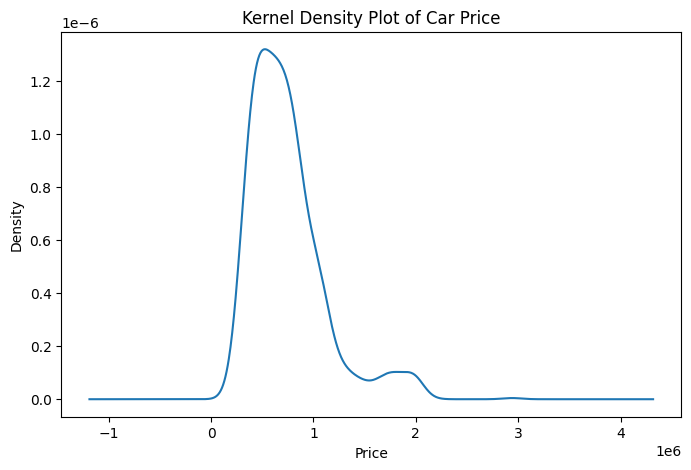

In [25]:
fig, ax = plt.subplots()
cars["Price"].plot(kind="kde", ax=ax)
ax.set_title("Kernel Density Plot of Car Price")
ax.set_xlabel("Price")
plt.show()

In [26]:
body_summary = cars.groupby("Body_Type")["Price"].describe().sort_values("mean", ascending=False)
body_summary

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
suv,206.0000,"1,176,495.1456","417,479.0282","559,000.0000","860,000.0000","1,065,000.0000","1,491,250.0000","2,100,000.0000"
sedan,227.0000,"809,784.1410","286,736.7701","368,000.0000","598,000.0000","772,000.0000","968,500.0000","2,941,000.0000"
crossover,21.0000,"705,095.2381","72,849.7802","608,000.0000","638,000.0000","706,000.0000","749,000.0000","883,000.0000"
muv,38.0000,"626,421.0526","184,093.4885","328,000.0000","489,750.0000","621,500.0000","738,500.0000","1,091,000.0000"
hatchback,484.0000,"533,977.2727","173,086.7298","188,000.0000","401,750.0000","509,000.0000","661,000.0000","1,107,000.0000"


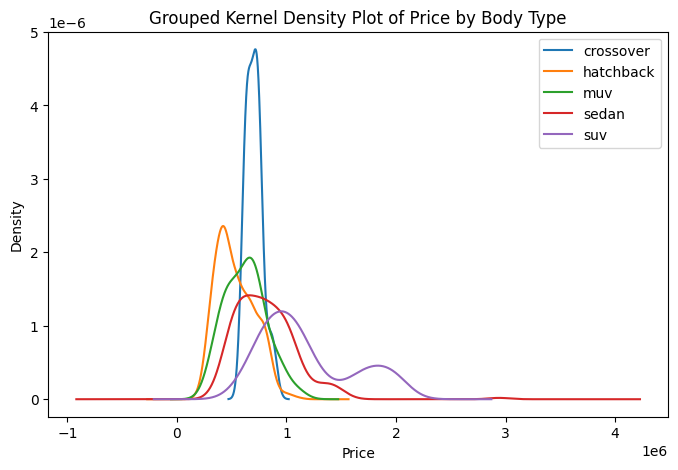

In [27]:
fig, ax = plt.subplots()
for name, grp in cars.groupby("Body_Type"):
    grp["Price"].plot(kind="kde", ax=ax, label=name)
ax.set_title("Grouped Kernel Density Plot of Price by Body Type")
ax.set_xlabel("Price")
ax.legend()
plt.show()

Analyzing the table, the body type with the highest mean price is the most expensive on average, and the body type with the largest standard deviation varies the most in prices.

### Q3.2

In [28]:
mod_q3_seats_linear = smf.ols("Price ~ Seating_Capacity", data=cars).fit()
print(mod_q3_seats_linear.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0245
Time:                        22:59:52   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

In [29]:
seat_slope = mod_q3_seats_linear.params["Seating_Capacity"]
print(
    f"Slope on Seating_Capacity: {seat_slope:,.4f}. "
    f"This means one additional seat is associated with an average change of {seat_slope:,.4f} in price."
)

Slope on Seating_Capacity: 59,267.9980. This means one additional seat is associated with an average change of 59,267.9980 in price.


In [30]:
mod_q3_seats_cat = smf.ols("Price ~ C(Seating_Capacity)", data=cars).fit()
print(mod_q3_seats_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000267
Time:                        23:00:11   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [31]:
seat_means = cars.groupby("Seating_Capacity")["Price"].mean().sort_index()
seat_means

Seating_Capacity
4     188,000.0000
5     734,483.8710
6   1,644,000.0000
7     923,948.7179
8     459,800.0000
Name: Price, dtype: float64

We can see if the relationship is linear in seats by comparing the linear-regression fit using one slope for seat count, and the group means from categorical specification. If the average prices move in steady pattern as seats increase, then it is reasonable to treat seats as numeric. On the other hand, if the means are not consistent and jump around, then the linear specification may be too restrictive.

### Q3.3

In [32]:
current_year = pd.Timestamp.today().year
cars["Age"] = current_year - cars["Make_Year"]
cars[["Make_Year", "Age"]].head()

,Make_Year,Age
0,2017,9
1,2016,10
2,2019,7
3,2017,9
4,2017,9


In [33]:
degree_results = []

X_age = cars[["Age"]].values
y_price = cars["Price"].values
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for degree in range(1, 11):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lr", LinearRegression())
    ])
    neg_mse_scores = cross_val_score(
        model, X_age, y_price,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
    rmse = np.sqrt(-neg_mse_scores.mean())
    degree_results.append({"degree": degree, "cv_rmse": rmse})

degree_results = pd.DataFrame(degree_results).sort_values("cv_rmse")
degree_results

,degree,cv_rmse
6,7,"307,715.7211"
9,10,"307,924.5256"
7,8,"308,182.0545"
8,9,"308,231.4631"
4,5,"308,650.3451"
5,6,"308,802.4585"
3,4,"310,201.6090"
2,3,"311,035.6970"
0,1,"312,053.2776"
1,2,"312,082.8511"


In [34]:
best_degree = int(degree_results.iloc[0]["degree"])
print(f"Optimal polynomial degree by 10-fold CV: {best_degree}")

Optimal polynomial degree by 10-fold CV: 7


### Q3.4

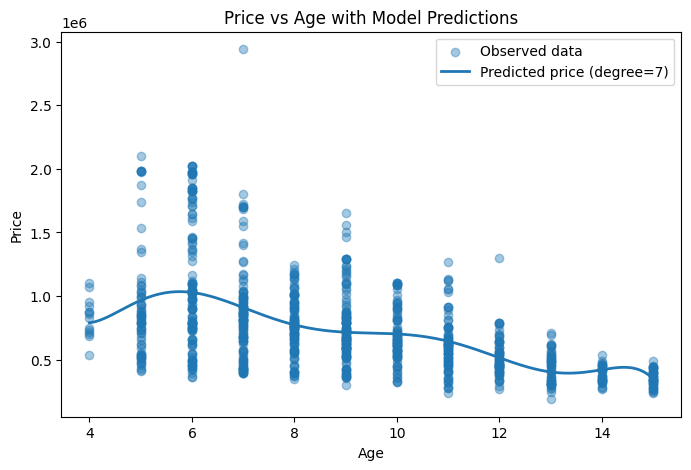

In [35]:
best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("lr", LinearRegression())
])
best_model.fit(X_age, y_price)

age_grid = np.linspace(cars["Age"].min(), cars["Age"].max(), 200).reshape(-1, 1)
pred_grid = best_model.predict(age_grid)

fig, ax = plt.subplots()
ax.scatter(cars["Age"], cars["Price"], alpha=0.4, label="Observed data")
ax.plot(age_grid, pred_grid, linewidth=2, label=f"Predicted price (degree={best_degree})")
ax.set_title("Price vs Age with Model Predictions")
ax.set_xlabel("Age")
ax.set_ylabel("Price")
ax.legend()
plt.show()

When looking at this graph, the model is working well if the fitted curve captures the main decline or curvature in prices as cars age. If the line misses the clear patterns or varies too much, then it may be over or under fitted.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [36]:
heart = pd.read_csv("./data/heart_hw.csv")
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [37]:
heart.columns = [c.strip().replace(" ", "_") for c in heart.columns]

rename_map = {}
for c in heart.columns:
    lc = c.lower()
    if lc == "y":
        rename_map[c] = "y"
    elif lc == "age":
        rename_map[c] = "age"
    elif "transplant" in lc:
        rename_map[c] = "transplant"
heart = heart.rename(columns=rename_map)

required_cols_q4 = ["y", "age", "transplant"]
print("Columns after renaming:", heart.columns.tolist())
print("Missing required columns:", [c for c in required_cols_q4 if c not in heart.columns])

heart = heart[required_cols_q4].dropna().copy()
heart["y"] = pd.to_numeric(heart["y"], errors="coerce")
heart["age"] = pd.to_numeric(heart["age"], errors="coerce")
heart = heart.dropna().copy()

heart["transplant"] = heart["transplant"].astype(str).str.lower().str.strip()

Columns after renaming: ['Unnamed:_0', 'age', 'transplant', 'y']
Missing required columns: []


In [38]:
heart.head()

,y,age,transplant
0,0,53,control
1,0,43,control
2,0,52,control
3,0,52,control
4,0,54,control


### Q4.1

In [39]:
survival_rates = heart.groupby("transplant")["y"].mean()
survival_rates

transplant
control     0.1176
treatment   0.3478
Name: y, dtype: float64

In [40]:
control_rate = survival_rates.loc["control"]
treatment_rate = survival_rates.loc["treatment"]
ate = treatment_rate - control_rate

print(f"Control survival proportion:   {control_rate:.4f}")
print(f"Treatment survival proportion: {treatment_rate:.4f}")
print(f"ATE (treatment - control):     {ate:.4f}")

Control survival proportion:   0.1176
Treatment survival proportion: 0.3478
ATE (treatment - control):     0.2302


### Q4.2

In [41]:
mod_q4_basic = smf.ols("y ~ C(transplant)", data=heart).fit()
print(mod_q4_basic.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0133
Time:                        23:15:54   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

With an intercept and one omitted category, the intercept is the average survival probability for the baseline group, and the transplant coefficient is the difference in mean survival probability between treatment and control. In other words, this regression reproduces the same comparison as the treatment-control average from part 1.

### Q4.3

In [42]:
mod_q4_age = smf.ols("y ~ C(transplant) + age", data=heart).fit()
print(mod_q4_age.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000357
Time:                        23:17:23   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

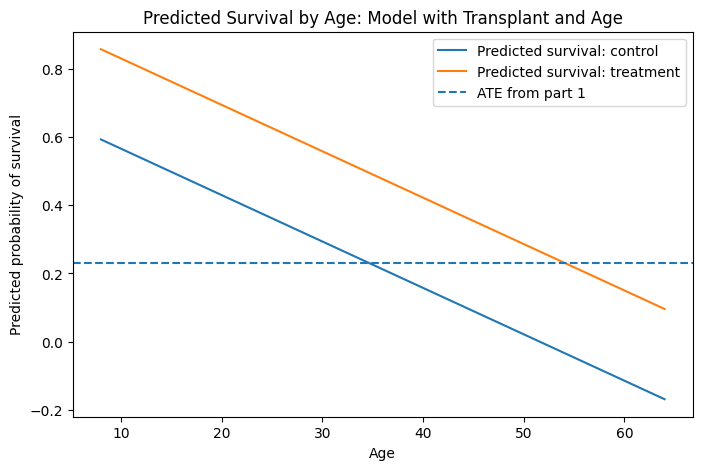

In [43]:
age_grid = np.linspace(heart["age"].min(), heart["age"].max(), 200)

pred_control = pd.DataFrame({"transplant": ["control"] * len(age_grid), "age": age_grid})
pred_treat = pd.DataFrame({"transplant": ["treatment"] * len(age_grid), "age": age_grid})

yhat_control = mod_q4_age.predict(pred_control)
yhat_treat = mod_q4_age.predict(pred_treat)

fig, ax = plt.subplots()
ax.plot(age_grid, yhat_control, label="Predicted survival: control")
ax.plot(age_grid, yhat_treat, label="Predicted survival: treatment")
ax.axhline(ate, linestyle="--", label="ATE from part 1")
ax.set_title("Predicted Survival by Age: Model with Transplant and Age")
ax.set_xlabel("Age")
ax.set_ylabel("Predicted probability of survival")
ax.legend()
plt.show()


Interpret this model, the intercept is the predicted survival probability for the baseline transplant group when age = 0, and the age slope is the change in predicted survival probability associated with a one-year increase in age, holding transplant status fixed. Also, the transplant coefficient is the treatment-control difference holding age fixed. Since age = 0 does not matter that much in this context, the intercept is mostly a mathematical anchor, and the slopes and predicted values across realistic ages hold more importance.

### Q4.4

In [44]:
mod_q4_interact = smf.ols("y ~ C(transplant) * age", data=heart).fit()
print(mod_q4_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000310
Time:                        23:20:33   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

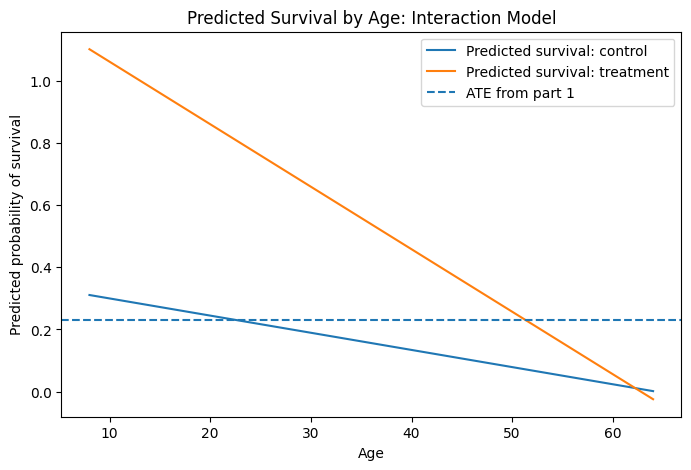

In [45]:
yhat_control_i = mod_q4_interact.predict(pred_control)
yhat_treat_i = mod_q4_interact.predict(pred_treat)

fig, ax = plt.subplots()
ax.plot(age_grid, yhat_control_i, label="Predicted survival: control")
ax.plot(age_grid, yhat_treat_i, label="Predicted survival: treatment")
ax.axhline(ate, linestyle="--", label="ATE from part 1")
ax.set_title("Predicted Survival by Age: Interaction Model")
ax.set_xlabel("Age")
ax.set_ylabel("Predicted probability of survival")
ax.legend()
plt.show()

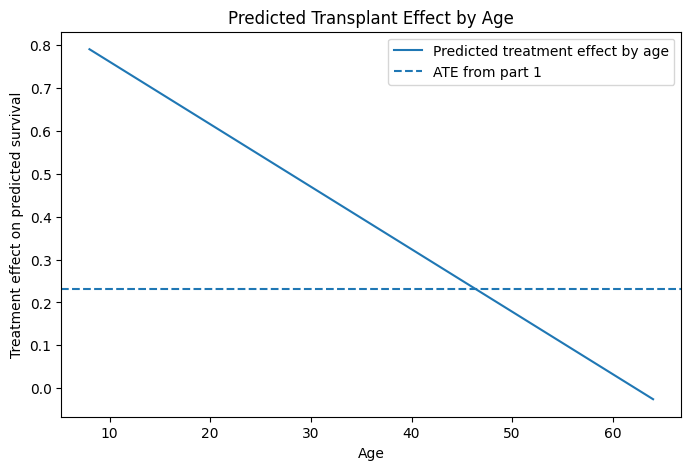

In [46]:
impact_by_age = yhat_treat_i - yhat_control_i

fig, ax = plt.subplots()
ax.plot(age_grid, impact_by_age, label="Predicted treatment effect by age")
ax.axhline(ate, linestyle="--", label="ATE from part 1")
ax.set_title("Predicted Transplant Effect by Age")
ax.set_xlabel("Age")
ax.set_ylabel("Treatment effect on predicted survival")
ax.legend()
plt.show()

Allowing the interaction means that the effect of transplant is no longer forced to be the same at every age. If the treatment-effect line does change with age, then the constant ATE from part 1 is hiding important heterogeneity across patients.

### Q4.5

In [47]:
def rmse_cv_binary_formula(formula, data, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []
    for train_idx, test_idx in kf.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]
        fit = smf.ols(formula, data=train).fit()
        preds = fit.predict(test)
        rmse = np.sqrt(np.mean((test["y"] - preds) ** 2))
        rmses.append(rmse)
    return np.mean(rmses), np.std(rmses)

cv_results_q4 = pd.DataFrame({
    "model": [
        "y ~ C(transplant)",
        "y ~ C(transplant) + age",
        "y ~ C(transplant) * age"
    ],
    "mean_rmse": [
        rmse_cv_binary_formula("y ~ C(transplant)", heart)[0],
        rmse_cv_binary_formula("y ~ C(transplant) + age", heart)[0],
        rmse_cv_binary_formula("y ~ C(transplant) * age", heart)[0]
    ],
    "sd_rmse": [
        rmse_cv_binary_formula("y ~ C(transplant)", heart)[1],
        rmse_cv_binary_formula("y ~ C(transplant) + age", heart)[1],
        rmse_cv_binary_formula("y ~ C(transplant) * age", heart)[1]
    ]
}).sort_values("mean_rmse")

cv_results_q4

,model,mean_rmse,sd_rmse
2,y ~ C(transplant) * age,0.4130,0.0677
1,y ~ C(transplant) + age,0.4167,0.0603
0,y ~ C(transplant),0.4365,0.0503


### Q4.6

This model has many worrying attributes that raises cautions before deployment.
1. Fairness concerns: The model could systematically give a disadvantage to groups such as older patients if historical treatment patterns reflect inequities.
2. Selection bias and confounding: People who receive transplants are not randomly assigned, which means that a bias could exists. Sicker or healthier patients may be more likely to receive treatment, so the estimated effect may not be causal.
3. Small-data instability: If the sample is not large enough, the estimated treatment effects can be noisy.
4. Linear probability model limitations: Predicted values may fall outside the 0 to 1 range, and the linear structure may oversimplify survival relationships.
5. Ethical deployment risk: A predictive model should be able lto support clinical judgment, not replace it, especially in high-stakes medical decisions.

In conclusion, although the model has reasonably good results, that does not lead to the conclusion that it automatically qualifies to be used to decide which patients gets treatment.